# 입력 feature 선택 및 HistGradientBoostingClassifier 모델 학습 및 검증

- feature 설정: `services/ai/configs/feature_config.yaml`
- 데이터: `services/ai/data/behavior/trial_*.json`
- 저장: `services/ai/train/model_joblib/hist_gradient_boosting_classifier/model.joblib`


## 1. 데이터 준비


In [1]:
from __future__ import annotations

import json
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import yaml

SEED = 42
TEST_SIZE = 0.2
MODEL_NAME = "hist_gradient_boosting_classifier"
LABEL_MAPPING = {"human": 0, "macro": 1}

# 데이터 경로 설정
ROOT = Path.cwd()

if ROOT.name != "model_experiment":
    raise Exception("데이터를 찾기 위해 작업 디렉토리 확인 필요")

CONFIG_PATH = Path("../../configs/feature_config.yaml")
DATA_DIR = Path("../../data/behavior")
MODEL_DIR = Path("../model_joblib") / MODEL_NAME

print("ROOT:", ROOT)
print("CONFIG_PATH:", CONFIG_PATH)
print("DATA_DIR:", DATA_DIR)
print("MODEL_DIR:", MODEL_DIR)


ROOT: /Users/imch/workspace/00_ing/S14P31A203/services/ai/train/model_experiment
CONFIG_PATH: ../../configs/feature_config.yaml
DATA_DIR: ../../data/behavior
MODEL_DIR: ../model_joblib/hist_gradient_boosting_classifier


In [2]:
with CONFIG_PATH.open("r", encoding="utf-8") as f:
    feature_config = yaml.safe_load(f)

FEATURE_GROUPS = feature_config["groups"]
FEATURE_NAME_KO = feature_config.get("names_ko", {})
EXCLUDE_COLS = set(feature_config.get("exclude", []))
FEATURE_NAMES = [feature for group in FEATURE_GROUPS.values() for feature in group]

def extract_label(payload: dict) -> str | None:
    label = payload.get("label")
    if isinstance(label, str):
        return label
    summary = payload.get("summary")
    if isinstance(summary, dict) and isinstance(summary.get("label"), str):
        return summary["label"]
    return None


def parse_path_pattern(value: object) -> tuple[float, float]:
    if not isinstance(value, str):
        return (np.nan, np.nan)

    parts = value.split("|", 1)
    if len(parts) != 2:
        return (np.nan, np.nan)

    distance_text = parts[0].replace("px", "").strip()
    straightness_text = parts[1].replace("straight", "").strip()

    try:
        return (float(distance_text), float(straightness_text))
    except ValueError:
        return (np.nan, np.nan)


def load_trials(data_dir: Path) -> pd.DataFrame:
    rows: list[dict] = []
    counters = {"total": 0, "kept": 0, "no_label": 0, "skipped_other": 0}

    for path in sorted(data_dir.glob("trial_*.json")):
        counters["total"] += 1
        payload = json.loads(path.read_text(encoding="utf-8"))

        label = extract_label(payload)
        if label is None:
            counters["no_label"] += 1
            continue
        if label not in LABEL_MAPPING:
            counters["skipped_other"] += 1
            continue

        summary = payload.get("summary") or {}
        metrics = payload.get("metrics") or {}
        row = {
            "trial_id": int(payload.get("trialId") or payload.get("trial_id") or 0),
            "label": label,
        }
        if isinstance(summary, dict):
            row.update(summary)
        if isinstance(metrics, dict):
            row.update(metrics)
        rows.append(row)
        counters["kept"] += 1

    df = pd.DataFrame(rows).sort_values("trial_id").reset_index(drop=True)
    print("load counters:", counters)
    return df


def add_pre_click_path_features(df: pd.DataFrame) -> None:
    for win in [300, 500]:
        raw_col = f"pre_click_mouse_path_pattern_{win}ms"
        dist_col = f"pre_click_path_{win}ms_total_distance_px"
        straight_col = f"pre_click_path_{win}ms_straightness"
        if raw_col not in df.columns or (dist_col in df.columns and straight_col in df.columns):
            continue
        parsed = df[raw_col].map(parse_path_pattern)
        df[dist_col] = parsed.map(lambda x: x[0])
        df[straight_col] = parsed.map(lambda x: x[1])


df = load_trials(DATA_DIR)
add_pre_click_path_features(df)

display(df["label"].value_counts().rename_axis("label").reset_index(name="count"))
print("configured feature count:", len(FEATURE_NAMES))
display(pd.DataFrame({"feature": FEATURE_NAMES, "feature_ko": [FEATURE_NAME_KO.get(f, f) for f in FEATURE_NAMES]}))


load counters: {'total': 324, 'kept': 324, 'no_label': 0, 'skipped_other': 0}


,label,count
0,macro,164
1,human,160


configured feature count: 44


,feature,feature_ko
0,time_to_first_click_ms,첫 클릭 시간
1,time_from_element_visible_to_click_ms,노출 후 클릭
2,time_from_element_clickable_to_click_ms,활성 후 클릭
3,inter_click_interval_ms,클릭 간격
4,click_sequence_consistency_score,순서 일관성
5,click_position_repeat_rate,좌표 반복률
6,click_offset_from_element_center_px,중심 오차
7,click_offset_variance_px,오차 분산
8,double_click_rate,더블클릭 비율
9,misclick_rate,오클릭 비율


## 2. 데이터 전처리


In [3]:
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler

present_features = [f for f in FEATURE_NAMES if f in df.columns]
missing_features = [f for f in FEATURE_NAMES if f not in df.columns]

X_all = df[present_features].apply(pd.to_numeric, errors="coerce")
usable_features = [f for f in present_features if X_all[f].notna().any()]
dropped_all_nan = [f for f in present_features if f not in usable_features]

X = X_all[usable_features]
y = df["label"].map(LABEL_MAPPING).astype(int).to_numpy()
feature_names = list(X.columns)

x_train, x_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y,
)

n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
SCALE_POS_WEIGHT = n_neg / max(n_pos, 1)

print("usable features:", len(usable_features), "/", len(FEATURE_NAMES))
print("missing features:", missing_features)
print("dropped all-NaN features:", dropped_all_nan)
print("train shape:", x_train.shape, "val shape:", x_val.shape)
print("train class counts:", dict(zip(*np.unique(y_train, return_counts=True))))
print("val class counts:", dict(zip(*np.unique(y_val, return_counts=True))))
print("scale_pos_weight:", SCALE_POS_WEIGHT)


usable features: 44 / 44
missing features: []
dropped all-NaN features: []
train shape: (259, 44) val shape: (65, 44)
train class counts: {np.int64(0): np.int64(128), np.int64(1): np.int64(131)}
val class counts: {np.int64(0): np.int64(32), np.int64(1): np.int64(33)}
scale_pos_weight: 0.9770992366412213


## 3. 모델 준비


In [4]:
from sklearn.ensemble import HistGradientBoostingClassifier

def build_model(seed: int = SEED):
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "clf",
                HistGradientBoostingClassifier(
                    learning_rate=0.05,
                    max_iter=300,
                    max_leaf_nodes=15,
                    l2_regularization=0.01,
                    random_state=seed,
                ),
            ),
        ]
    )


def predict_macro_proba(fitted_model, x) -> np.ndarray:
    if hasattr(fitted_model, "predict_proba"):
        return np.asarray(fitted_model.predict_proba(x))[:, 1]
    decision = np.asarray(fitted_model.decision_function(x), dtype=float)
    return 1.0 / (1.0 + np.exp(-decision))


def evaluate_binary(y_true: np.ndarray, proba: np.ndarray, threshold: float = 0.5) -> dict[str, float]:
    pred = (proba >= threshold).astype(int)
    out = {
        "accuracy": float(accuracy_score(y_true, pred)),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "average_precision": float(average_precision_score(y_true, proba)),
    }
    try:
        out["roc_auc"] = float(roc_auc_score(y_true, proba))
    except ValueError:
        out["roc_auc"] = float("nan")
    try:
        out["log_loss"] = float(log_loss(y_true, proba, labels=[0, 1]))
    except ValueError:
        out["log_loss"] = float("nan")
    return out


model = build_model(SEED)
model


,steps,"[('imputer', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,loss,'log_loss'


## 4. 모델 학습


In [5]:
model.fit(x_train, y_train)

train_proba = predict_macro_proba(model, x_train)
val_proba = predict_macro_proba(model, x_val)

train_metrics = evaluate_binary(y_train, train_proba)
val_metrics = evaluate_binary(y_val, val_proba)

metrics_df = pd.DataFrame(
    [
        {"split": "train", **train_metrics},
        {"split": "validation", **val_metrics},
    ]
)
display(metrics_df)

cm = confusion_matrix(y_val, (val_proba >= 0.5).astype(int), labels=[0, 1])
cm_df = pd.DataFrame(cm, index=["actual_human", "actual_macro"], columns=["pred_human", "pred_macro"])
display(cm_df)


,split,accuracy,precision,recall,f1,average_precision,roc_auc,log_loss
0,train,1.0,1.0,1.0,1.0,1.0,1.0,0.000016
1,validation,1.0,1.0,1.0,1.0,1.0,1.0,0.000016


,pred_human,pred_macro
actual_human,32,0
actual_macro,0,33


## 5. 모델 검증


In [6]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_result = cross_validate(
    build_model(SEED),
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False,
)

cv_summary = pd.DataFrame(
    [
        {
            "metric": metric.replace("test_", ""),
            "mean": float(values.mean()),
            "std": float(values.std(ddof=1)),
        }
        for metric, values in cv_result.items()
        if metric.startswith("test_")
    ]
).sort_values("metric")

display(cv_summary)


,metric,mean,std
0,accuracy,1.0,0.0
5,average_precision,1.0,0.0
3,f1,1.0,0.0
1,precision,1.0,0.0
2,recall,1.0,0.0
4,roc_auc,1.0,0.0


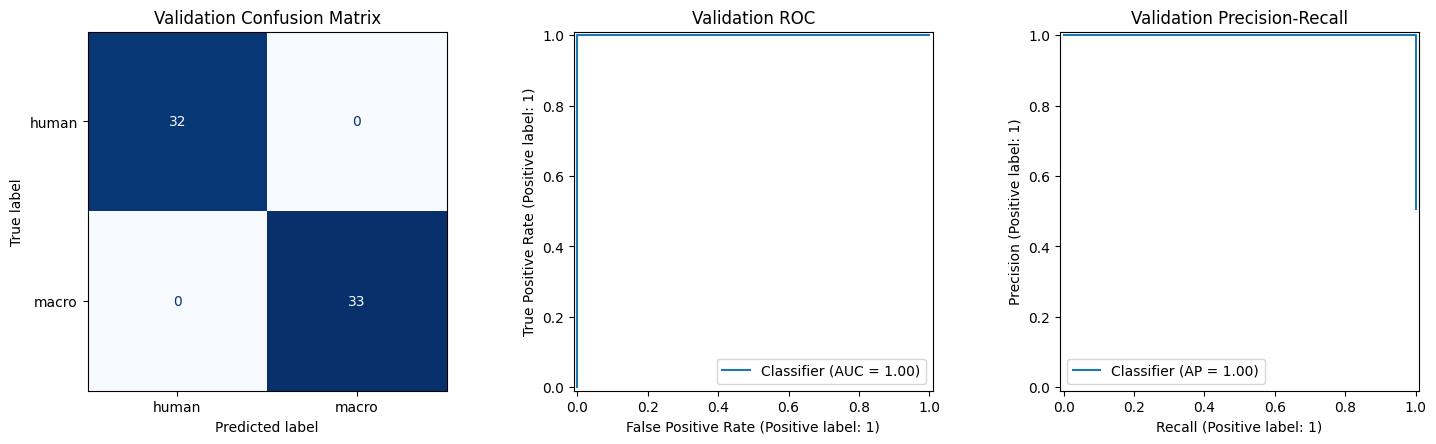

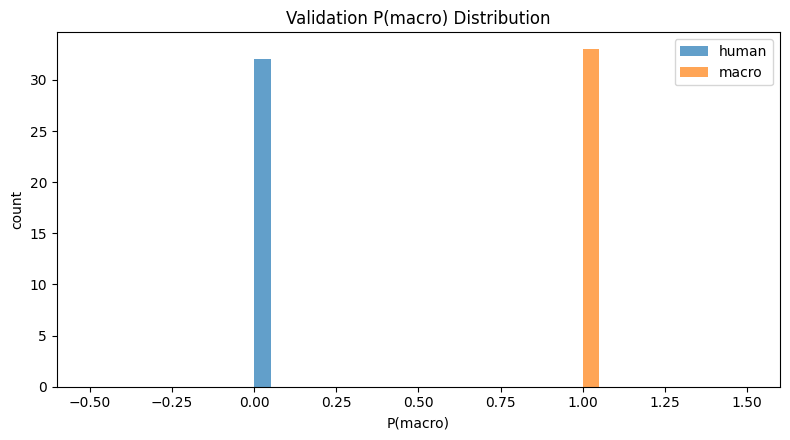

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    (val_proba >= 0.5).astype(int),
    display_labels=["human", "macro"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Validation Confusion Matrix")

RocCurveDisplay.from_predictions(y_val, val_proba, ax=axes[1])
axes[1].set_title("Validation ROC")

PrecisionRecallDisplay.from_predictions(y_val, val_proba, ax=axes[2])
axes[2].set_title("Validation Precision-Recall")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4.5))
plt.hist(val_proba[y_val == 0], bins=20, alpha=0.7, label="human")
plt.hist(val_proba[y_val == 1], bins=20, alpha=0.7, label="macro")
plt.title("Validation P(macro) Distribution")
plt.xlabel("P(macro)")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()


In [8]:
# HistGradientBoostingClassifier는 sklearn 기본 feature_importances_가 없어 permutation importance로 확인합니다.
perm = permutation_importance(model, x_val, y_val, n_repeats=20, random_state=SEED, scoring="roc_auc")
importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "feature_ko": [FEATURE_NAME_KO.get(f, f) for f in feature_names],
        "importance": perm.importances_mean,
        "importance_std": perm.importances_std,
    }
).sort_values("importance", ascending=False)
display(importance_df.head(30))


,feature,feature_ko,importance,importance_std
6,click_offset_from_element_center_px,중심 오차,0.486269,0.071253
0,time_to_first_click_ms,첫 클릭 시간,0.000000,0.000000
33,pre_click_path_500ms_straightness,500ms 경로 직선성,0.000000,0.000000
25,mouse_hover_dwell_time_ms,평균 dwell,0.000000,0.000000
26,mouse_stop_segment_count,정지 구간 수,0.000000,0.000000
27,mousemove_event_rate,mousemove 빈도,0.000000,0.000000
28,inter_element_move_interval_std_ms,이동 간격 표준편차,0.000000,0.000000
29,edge_or_fixed_point_visit_rate,고정점 방문률,0.000000,0.000000
30,pre_click_path_300ms_total_distance_px,300ms 경로 총거리,0.000000,0.000000
31,pre_click_path_300ms_straightness,300ms 경로 직선성,0.000000,0.000000


## 6. 모델 저장


In [9]:
import joblib

MODEL_DIR.mkdir(parents=True, exist_ok=True)
model_path = MODEL_DIR / "model.joblib"
meta_path = MODEL_DIR / "meta.json"
metrics_path = MODEL_DIR / "metrics.json"

joblib.dump(model, model_path)

meta = {
    "model_name": MODEL_NAME,
    "trained_at": datetime.now().isoformat(timespec="seconds"),
    "label_mapping": LABEL_MAPPING,
    "feature_config": str(CONFIG_PATH),
    "data_dir": str(DATA_DIR),
    "feature_names": feature_names,
    "missing_features": missing_features,
    "dropped_all_nan_features": dropped_all_nan,
    "n_samples": int(X.shape[0]),
    "n_train": int(x_train.shape[0]),
    "n_validation": int(x_val.shape[0]),
    "test_size": TEST_SIZE,
    "seed": SEED,
}
metrics_payload = {
    "train": train_metrics,
    "validation": val_metrics,
    "cv": cv_summary.to_dict(orient="records"),
    "confusion_matrix_validation": cm.astype(int).tolist(),
}

meta_path.write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8")
metrics_path.write_text(json.dumps(metrics_payload, ensure_ascii=False, indent=2), encoding="utf-8")

print("saved model:", model_path)
print("saved meta:", meta_path)
print("saved metrics:", metrics_path)


saved model: ../model_joblib/hist_gradient_boosting_classifier/model.joblib
saved meta: ../model_joblib/hist_gradient_boosting_classifier/meta.json
saved metrics: ../model_joblib/hist_gradient_boosting_classifier/metrics.json


## 7. 결과 리포트


In [10]:
print(f"MODEL: {MODEL_NAME}")
print("Validation metrics")
display(pd.DataFrame([val_metrics]))
print("5-fold CV summary")
display(cv_summary)
print("Artifacts")
print(MODEL_DIR)


MODEL: hist_gradient_boosting_classifier
Validation metrics


,accuracy,precision,recall,f1,average_precision,roc_auc,log_loss
0,1.0,1.0,1.0,1.0,1.0,1.0,0.000016


5-fold CV summary


,metric,mean,std
0,accuracy,1.0,0.0
5,average_precision,1.0,0.0
3,f1,1.0,0.0
1,precision,1.0,0.0
2,recall,1.0,0.0
4,roc_auc,1.0,0.0


Artifacts
../model_joblib/hist_gradient_boosting_classifier
